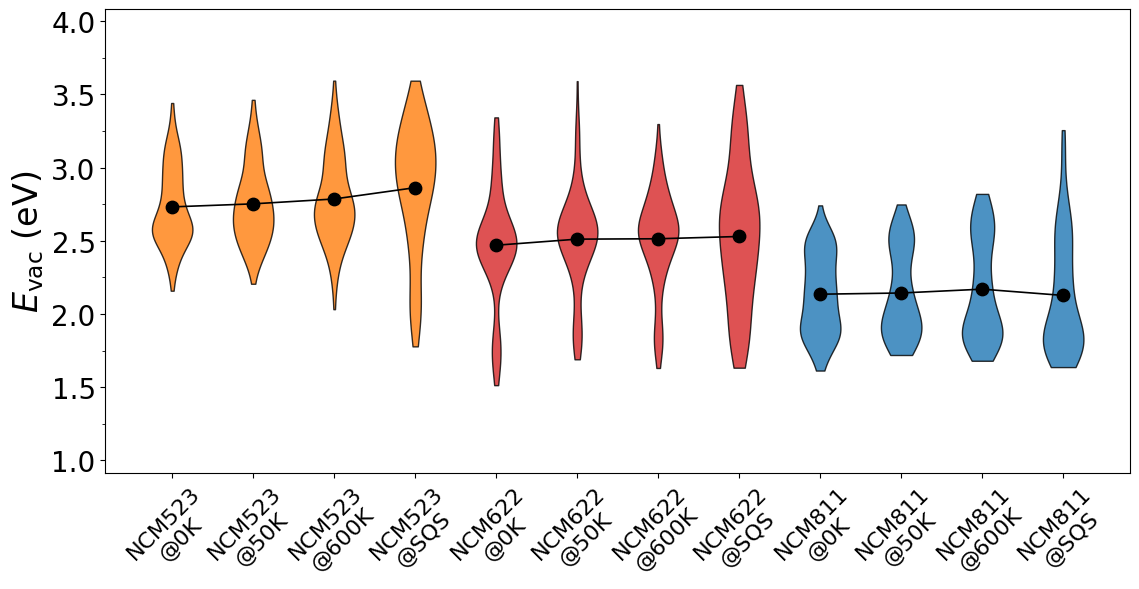

In [6]:
'''
    This program plots oxygen-vcancy formation energy in different NCM compounds.

    Extract: Data/OxygenBinding.tgz to access the O-vacancy formation energy data.

    Created on Dec 12, 2024 at RISM (Shinshu University)
    Last update: Aug 03, 2026 16:04 JST

    Copyright © 2024-2026 Quang Nguyen. All rights reserved.
'''

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

# Compound labels and corresponding data files
os.chdir("./Data/OxygenBinding.tgz")
compound_labels = ['NCM523@0K', 'NCM523@50K', 'NCM523@600K', 'NCM523@SQS',
                   'NCM622@0K', 'NCM622@50K', 'NCM622@600K', 'NCM622@SQS',
                   'NCM811@0K', 'NCM811@50K', 'NCM811@600K', 'NCM811@SQS']

energy_files = ['NCM523_Stable_Evacform.dat', 'NCM523_50K_Evacform.dat', 'NCM523_600K_Evacform.dat', 'NCM523_SQS_Evacform.dat',
                'NCM622_Stable_Evacform.dat', 'NCM622_50K_Evacform.dat', 'NCM622_600K_Evacform.dat', 'NCM622_SQS_Evacform.dat',
                'NCM811_Stable_Evacform.dat', 'NCM811_50K_Evacform.dat', 'NCM811_600K_Evacform.dat', 'NCM811_SQS_Evacform.dat']

# Read all data
energy_data = []
for file in energy_files:
    with open(file, 'r') as f:
        values = list(map(float, f.readline().split()))
        energy_data.append(values)

# Colors per NCM type
colors = {'NCM523': '#ff7f0e', 'NCM622': '#d62728', 'NCM811': '#1f77b4'}

# X-tick labels formatted
formatted_labels = [label.replace('@', '\n@') for label in compound_labels]

# Create violin plot
# plt.figure(figsize=(9.9, 6))  # For slide
plt.figure(figsize=(11.5, 6))
parts = plt.violinplot(energy_data, showmeans=False, showextrema=False, showmedians=False)

# Color violins by compound type
for i, pc in enumerate(parts['bodies']):
    ncm_type = compound_labels[i].split('@')[0]
    pc.set_facecolor(colors[ncm_type])
    pc.set_edgecolor('black')
    pc.set_alpha(0.8)

# Compute and plot averages
averages = [np.mean(vals) for vals in energy_data]
plt.scatter(range(1, len(energy_data)+1), averages, color='black', s=80, zorder=3, label='Mean')

# Connect average points within each NCM
compound_indices = {'NCM523': [0,1,2,3], 'NCM622': [4,5,6,7], 'NCM811': [8,9,10,11]}
for compound, idxs in compound_indices.items():
    x_vals = [i+1 for i in idxs]
    y_vals = [averages[i] for i in idxs]
    plt.plot(x_vals, y_vals, color='black', linewidth=1.2, zorder=2)

# Formatting
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.5))
plt.gca().yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
plt.ylim(1.0 - 0.5/6, 4.0 + 0.5/6)
plt.xticks(range(1, len(compound_labels) + 1), formatted_labels, rotation=45, fontsize=16)
plt.yticks(fontsize=20)
plt.ylabel(r'$E_{\mathrm{vac}}$ (eV)', fontsize=24)
plt.tight_layout()
plt.savefig('NCM_Evacform_0K_50K_600K_SQS_violin.png', dpi=300)
plt.show()